flow: define variables at first

then run functions

- inference and evaluation:
  - load the model, check logs, see samples

- inference with visualization:
  - run model over batch images, and save result locally

- metric confusion matrix:
  - check quantitative result

# variables

In [1]:
model_path = "/home/jupyter/test/ken/ftckpt/side_baseline/"
thres_list = [0.9] #best for this ckpt

# functions

In [2]:
#%pip install torch torchvision

In [3]:
import torch, torchvision
print(torch.__version__, torch.cuda.is_available())

torch.set_grad_enabled(False);

2.6.0+cu124 True


In [4]:
import torchvision.transforms as T

# standard PyTorch mean-std input image normalization
transform = T.Compose([
    T.Resize(800),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# for output bounding box post-processing
def box_cxcywh_to_xyxy(x):
    x_c, y_c, w, h = x.unbind(1)
    b = [(x_c - 0.5 * w), (y_c - 0.5 * h),
         (x_c + 0.5 * w), (y_c + 0.5 * h)]
    return torch.stack(b, dim=1)

def rescale_bboxes(out_bbox, size):
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * torch.tensor([img_w, img_h, img_w, img_h], dtype=torch.float32)
    return b

In [5]:
def filter_bboxes_from_outputs(outputs, img_size,
                               threshold=0.7):
  
  # keep only predictions with confidence above threshold
  probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
  keep = probas.max(-1).values > threshold

  probas_to_keep = probas[keep]

  # convert boxes from [0; 1] to image scales
  bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], img_size)
  
  return probas_to_keep, bboxes_scaled

In [6]:
# COCO classes
CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

In [7]:
import matplotlib.pyplot as plt

def plot_results(pil_img, prob=None, boxes=None):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    if prob is not None and boxes is not None:
      for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
          ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                    fill=False, color=c, linewidth=3))
          cl = p.argmax()
          text = f'{CLASSES[cl]}: {p[cl]:0.2f}'
          ax.text(xmin, ymin, text, fontsize=15,
                  bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()

In [8]:
first_class_index = 1
assert(first_class_index in [0, 1])

if first_class_index == 0:

  # There is one class, balloon, with ID n°0.

  num_classes = 1

  finetuned_classes = [
      'flaking',
  ]

  # The `no_object` class will be automatically reserved by DETR with ID equal
  # to `num_classes`, so ID n°1 here.  

else:

  # There is one class, balloon, with ID n°1.
  #
  # However, DETR assumes that indexing starts with 0, as in computer science,
  # so there is a dummy class with ID n°0.
  # Caveat: this dummy class is not the `no_object` class reserved by DETR.

  num_classes = 2

  finetuned_classes = [
      'N/A', 'flaking',
  ]

  # The `no_object` class will be automatically reserved by DETR with ID equal
  # to `num_classes`, so ID n°2 here.

print('First class index: {}'.format(first_class_index))  
print('Parameter num_classes: {}'.format(num_classes))
print('Fine-tuned classes: {}'.format(finetuned_classes))

First class index: 1
Parameter num_classes: 2
Fine-tuned classes: ['N/A', 'flaking']


# inference and evaluation

### Monitoring of training loss

Reference: https://github.com/lessw2020/Thunder-Detr/blob/master/View_your_training_results.ipynb

In [9]:
"""
Plotting utilities to visualize training logs.
"""
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# load log file(s) and plot
path = model_path
df = pd.read_json(f'{path}log.txt', lines=True)

def plot_log(fields, df):
    ewm_col = 0

    _, axs = plt.subplots(ncols=len(fields), figsize=(16, 5))

    for j, field in enumerate(fields):
        if field == 'mAP':
            coco_eval = pd.DataFrame(
                        np.stack(df.test_coco_eval_bbox.dropna().values)[:, 1]
                    ).ewm(com=ewm_col).mean()
            axs[j].plot(coco_eval, c='blue')
        else:
            axs[j].plot(df[f'train_{field}'], color='blue', linestyle='-')
            axs[j].plot(df[f'test_{field}'], color='blue', linestyle='--')

    for ax, field in zip(axs, fields):
            #ax.legend([Path(p).name for p in logs])
            ax.set_title(field)

As mentioned in the code of [`plot_logs`](https://github.com/facebookresearch/detr/blob/5e66b4cd15b2b182da347103dd16578d28b49d69/util/plot_utils.py#L13):
-   solid lines are training results,
-   dashed lines are validation results.

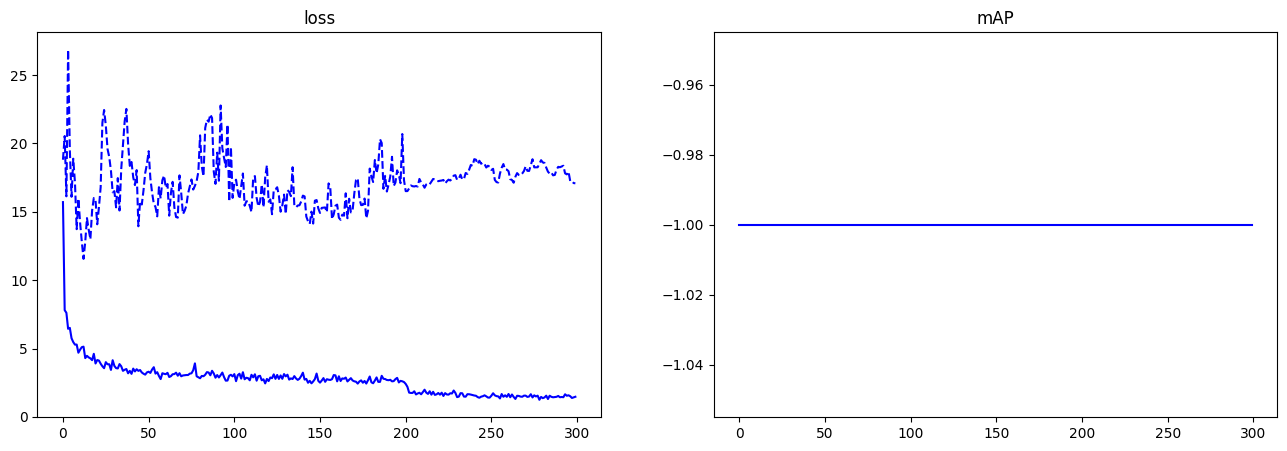

In [10]:
fields_of_interest = (
    'loss',
    'mAP',
    )

plot_log(fields_of_interest, df)

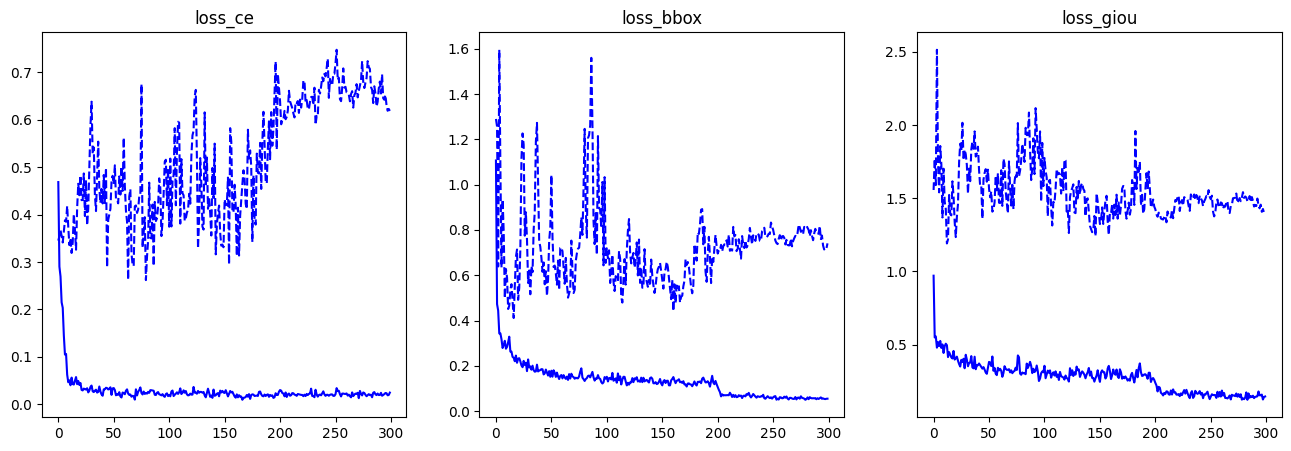

In [11]:
fields_of_interest = (
    'loss_ce',
    'loss_bbox',
    'loss_giou',
    )

plot_log(fields_of_interest, df)

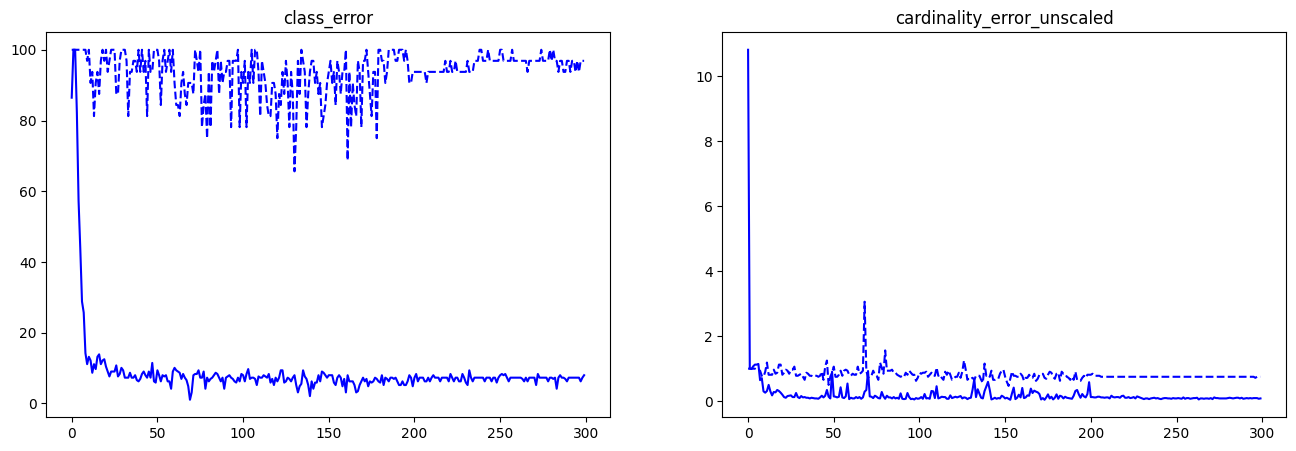

In [12]:
fields_of_interest = (
    'class_error',
    'cardinality_error_unscaled',
    )

plot_log(fields_of_interest, df)

### Load the fine-tuned model

- How to replace the classification head: https://github.com/facebookresearch/detr/issues/9#issuecomment-636391562

In [13]:
import torch
num_classes = 2
path = model_path
model = torch.hub.load('facebookresearch/detr',
                       'detr_resnet50',
                       pretrained=False,
                       num_classes=num_classes)

checkpoint = torch.load(f'{path}/checkpoint.pth',
                        map_location='cpu', weights_only=False)

model.load_state_dict(checkpoint['model'],
                      strict=False)

model.eval();

Using cache found in /home/loke_tictag_io/.cache/torch/hub/facebookresearch_detr_main
/opt/conda/envs/envken/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/envs/envken/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Visualize fine-tuned results

In [14]:
def plot_finetuned_results(pil_img, prob=None, boxes=None):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    if prob is not None and boxes is not None:
      for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
          ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                    fill=False, color=c, linewidth=3))
          cl = p.argmax()
          text = f'{finetuned_classes[cl]}: {p[cl]:0.2f}'
          ax.text(xmin, ymin, text, fontsize=15,
                  bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()
    

In [15]:
def run_worflow(my_image, my_model):
  # mean-std normalize the input image (batch-size: 1)
  img = transform(my_image).unsqueeze(0)

  # propagate through the model
  outputs = my_model(img)

  for threshold in thres_list:#set threshold list
    
    probas_to_keep, bboxes_scaled = filter_bboxes_from_outputs(outputs, my_image.size,
                                                              threshold=threshold)

    plot_finetuned_results(my_image,
                           probas_to_keep, 
                           bboxes_scaled)
finetuned_classes = [
      'N/A', 'flaking',
  ]

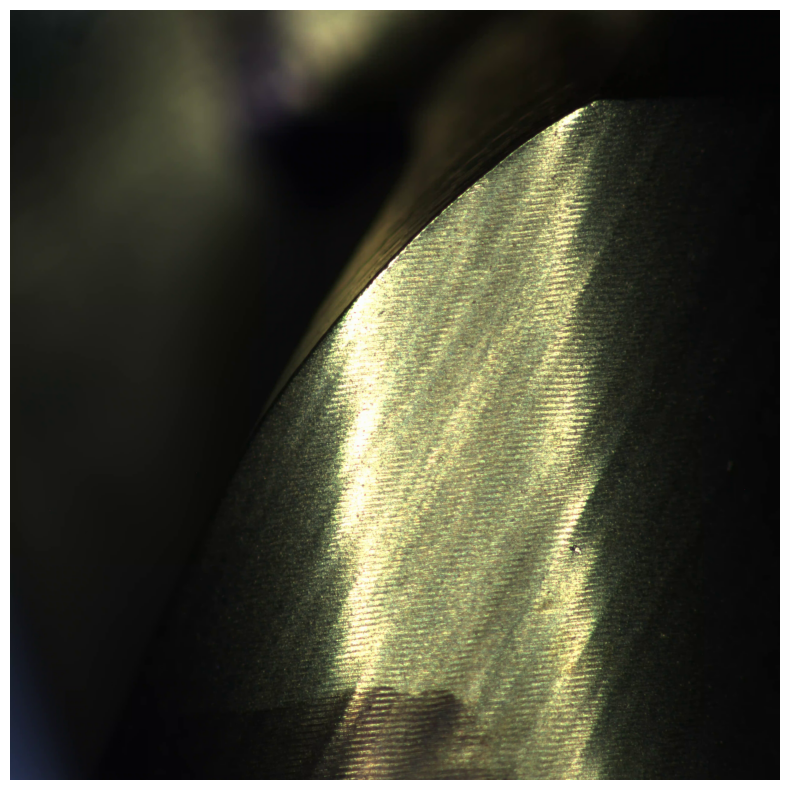

In [16]:
from PIL import Image

img_name = '/home/jupyter/test/ken/data_merge_side/val2017/0.png'
im = Image.open(img_name)

run_worflow(im,
            model)

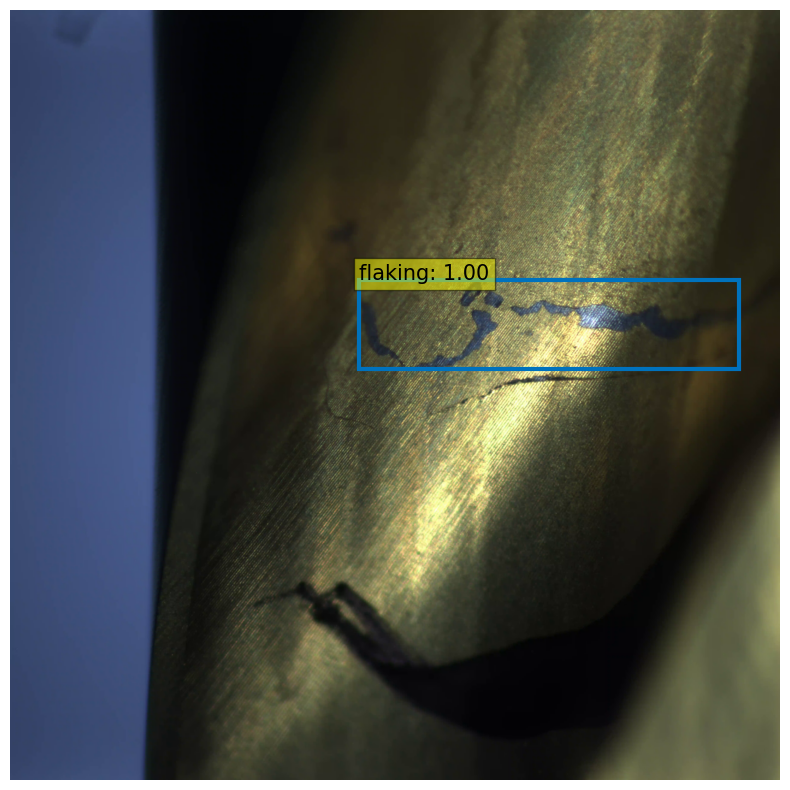

In [17]:
from PIL import Image

img_name = '/home/jupyter/test/ken/data_merge_side/train2017/21.png'
im = Image.open(img_name)

run_worflow(im,
            model)

# inference with visualization

name a folder for result

run model over images, and save to pred_folder

gt_folder is the ground truth

comparison folder: merge pred and gt together

- cookbook
- pred_vis
  - your pred folder
- comparison
  - your comparison

In [ ]:
folder = 'side_base'


gt_folder = '/home/jupyter/test/ken/gt_cust/side/val2017/'
pred_folder = f'/home/jupyter/test/ken/pred_vis/{folder}/'
comparison_folder = f'/home/jupyter/test/ken/comparison/{folder}/'

In [19]:
import cv2
import numpy as np

def plot_save(pil_img, output_name, prob=None, boxes=None):
    # Convert PIL image to OpenCV image (numpy array)
    cv_img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)
    
    # Draw rectangles and text on the image
    if prob is not None and boxes is not None:
        colors = COLORS * 100
        for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
            pt1 = (int(xmin), int(ymin))
            pt2 = (int(xmax), int(ymax))
            cv2.rectangle(cv_img, pt1, pt2, (255, 246, 132), 10)  # Blue color and larger thickness
            cl = p.argmax()
            text = f'{finetuned_classes[cl]}: {p[cl]:0.2f}'
            org = (int(xmin), int(ymin) - 10)  # Position text slightly above the rectangle
            cv2.rectangle(cv_img, org, (org[0] + len(text)*50, org[1] - 60), (137, 199, 231), -1)  # Colored box for text
            cv2.putText(cv_img, text, org, cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 0, 0), 3, cv2.LINE_AA)  # Black text with a larger font

    # Save the image
    cv2.imwrite(output_name, cv_img)

# Example usage:
# plot_save(pil_img, "output_image.png", prob=probs, boxes=bboxes)

def run_save(my_image, my_model, output_name):
  # mean-std normalize the input image (batch-size: 1)
  img = transform(my_image).unsqueeze(0)

  # propagate through the model
  outputs = my_model(img)

  for threshold in thres_list:
    
    probas_to_keep, bboxes_scaled = filter_bboxes_from_outputs(outputs, my_image.size,
                                                              threshold=threshold)

    plot_save(my_image, output_name,
                           probas_to_keep, 
                           bboxes_scaled)
finetuned_classes = [
      'N/A', 'flaking',
  ]

In [20]:
from PIL import Image
import os
import shutil

def make_folder(folder):
    if not os.path.exists(folder):
        os.makedirs(folder)
    else:
        shutil.rmtree(folder)
        os.makedirs(folder)
    return folder

make_folder('pred_vis/' + folder)
for i in range(0, 31):
    img_name = '/home/jupyter/test/ken/data_merge_side/val2017/{}.png'.format(i)
    im = Image.open(img_name)
    output_name = f'/home/jupyter/test/ken/pred_vis/{folder}/{i}.png'
    run_save(im,
            model,
            output_name)

In [21]:
import cv2
make_folder(comparison_folder)
def merge1(gt_folder, pred_folder, idx, output_folder):
    
    # Load the two images
    for i in range(idx):
        image1 = cv2.imread(f'{gt_folder}/{i}.png')
        image2 = cv2.imread(f'{pred_folder}/{i}.png')
        
        # Resize the images to have the same width
        width = max(image1.shape[1], image2.shape[1])
        image1 = cv2.resize(image1, (width, int(image1.shape[0] * width / image1.shape[1])))
        image2 = cv2.resize(image2, (width, int(image2.shape[0] * width / image2.shape[1])))

        # Merge the two images vertically
        merged_image = np.concatenate((image1, image2), axis=0)

        # Save the merged image
        cv2.imwrite(f"{output_folder}/{i}.png", merged_image)
    
    return output_folder

# Call the function to merge and save the images
merge1(gt_folder, pred_folder, 31, comparison_folder)

'/home/jupyter/test/ken/comparison/side_base/'

# metric confusion matrix

for a certain threshold, if no box predicted, no detection
if box predicted , calculated the l1 bounding box distance loss

In [22]:
from PIL import Image
import torchvision.transforms as T
def filter_bboxes_from_outputs(outputs, img_size,
                               threshold=0.7):
  
  # keep only predictions with confidence above threshold
  probas = outputs['pred_logits'].softmax(-1)[0, :, :-1]
  keep = probas.max(-1).values > threshold

  probas_to_keep = probas[keep]

  # convert boxes from [0; 1] to image scales
  bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0, keep], img_size)
  
  return probas_to_keep, bboxes_scaled

def box(img_path, threshold_list):
    #img_name = '/home/loke_tictag_io/test/ken/data_merge/val2017/0.png'
    im = Image.open(img_path)
    # standard PyTorch mean-std input image normalization
    transform = T.Compose([
        T.Resize(800),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    img = transform(im).unsqueeze(0)
    outputs = model(img)
    for threshold in threshold_list:
        probas_to_keep, bboxes_scaled = filter_bboxes_from_outputs(outputs, im.size, threshold=threshold)
    
    return probas_to_keep, bboxes_scaled

In [23]:
import os

# Specify the folder path
val_pos_folder = '/home/jupyter/test/ken/data_merge_side/val2017'
val_neg_folder1 = '/home/jupyter/test/ken/data_neg/side1'
val_neg_folder2 = '/home/jupyter/test/ken/data_neg/side2'


# Get all the file names in the folder
val_pos = [val_pos_folder + '/' + f for f in os.listdir(val_pos_folder)]
val_neg1 = [val_neg_folder1 + '/' + f for f in os.listdir(val_neg_folder1)]
val_neg2 = [val_neg_folder2 + '/' + f for f in os.listdir(val_neg_folder2)]

val_all = val_pos + val_neg1 + val_neg2
gt = [1 for _ in range(len(val_pos))] + [0 for _ in range(len(val_neg1))] + [0 for _ in range(len(val_neg2))]

In [24]:

pred = []
prob_list = []
box_list = []
for i in val_all:
    probas_to_keep, bboxes_scaled = box(i, thres_list)
    prob_list.append(probas_to_keep)
    box_list.append(bboxes_scaled)
    if bboxes_scaled.numel() == 0:
        pred.append(0)
    else:
        pred.append(1)

In [25]:
#make sure prob and box are empty at the same time
for i in range(len(box_list)):
    if box_list[i].numel() == 0:
        if prob_list[i].numel() != 0:
            print('Error')
        else:
            pass

In [26]:
from sklearn.metrics import classification_report
report = classification_report(gt, pred)
print("Classification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       179
           1       1.00      0.26      0.41        31

    accuracy                           0.89       210
   macro avg       0.94      0.63      0.67       210
weighted avg       0.90      0.89      0.86       210



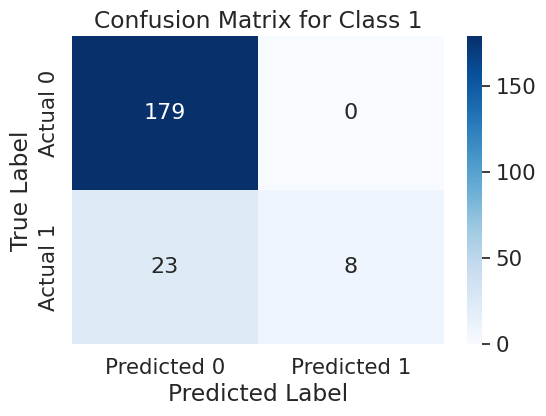

In [27]:
from sklearn.metrics import confusion_matrix
import numpy as np
# Get the confusion matrix
cm = confusion_matrix(gt, pred)

# Extract the values for class 1
tn, fp, fn, tp = cm.ravel()

# Display the confusion matrix for class 1
class_1_cm = np.array([[tn, fp], [fn, tp]])
#print("Confusion Matrix for Class 1:")
#print(class_1_cm)
import seaborn as sns
import matplotlib.pyplot as plt
# Plot the confusion matrix for class 1 using a heatmap
sns.set(font_scale=1.4)  # Adjust the font size if needed
plt.figure(figsize=(6, 4))
sns.heatmap(class_1_cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 16}, xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Class 1')
plt.show()

### error on bounding box

a good way to see how model performs in terms of bounding box, while the 'bbox_loss' in log shows that.

l1 loss box for only tp